# Anatomical Localization with `ndx-anatomical-localization`

This notebook demonstrates how to access and visualize the anatomical registration and localization
data stored in IBL widefield NWB files using the
[`ndx-anatomical-localization`](https://github.com/catalystneuro/ndx-anatomical-localization) NWB extension.

## Extension overview

The extension provides the following NWB types:

| Type | Description |
|---|---|
| `Space` | Coordinate frame definition: origin, units, and 3-letter axis orientation (e.g. `"RAS"`) |
| `AllenCCFv3Space` | Pre-defined `Space` for the Allen Mouse Brain Atlas CCFv3 (PIR, µm) |
| `AffineTransformation` | 3×3 affine matrix in homogeneous coordinates mapping source → registered space |
| `Landmarks` | Table of manually identified control points linking source pixels to atlas reference pixels |
| `AtlasRegistration` | Container grouping the images, transform, and landmarks produced by atlas registration |
| `AnatomicalCoordinatesImage` | Dense 2-D arrays of (x, y, z) physical coordinates and brain-region labels for every pixel in a registered image |
| `BrainRegionMasks` | Sparse table of `(x, y, brain_region_id)` rows — one per in-atlas pixel — for fast region-based extraction |
| `AnatomicalCoordinatesTable` | Table of 3-D coordinates for discrete objects (e.g. landmarks) in a named `Space` |
| `Localization` | Top-level container that groups `AnatomicalCoordinatesImage`, `BrainRegionMasks`, and `AnatomicalCoordinatesTable` objects |

> **Note:** `AnatomicalCoordinatesImage` and `BrainRegionMasks` are stored on the `Localization` container
> (`nwbfile.lab_meta_data["localization"]`), not on `AtlasRegistration`.

## Contents

1. [Setup and Data Access](#setup)
2. [Atlas Registration](#atlas-registration)
   - [Affine Transformation](#affine)
   - [Landmarks](#landmarks)
3. [Anatomical Coordinates Image](#aci)
4. [Brain Region Masks](#brm)
5. [Anatomical Coordinates Tables](#act)

---
## 1. Setup and Data Access <a id="setup"></a>

In [1]:
# IMPORTANT: import ndx_anatomical_localization BEFORE read_nwb.
# This executes all @register_class decorators so PyNWB maps
# custom types (e.g. BrainRegionMasks) to the correct Python classes.
import ndx_anatomical_localization  # noqa: F401

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from skimage.transform import SimilarityTransform
from pynwb import read_nwb

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [2]:
subject_id = "CSK-im-009"
session_id = "2864dca1-38d8-464c-9777-f6fdfd5e63b5"

nwbfile_path = (
    f"/Volumes/T9/data/IBL/nwbfiles/full/"
    f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_desc-processed_behavior+ophys.nwb"
)

nwbfile = read_nwb(nwbfile_path)
print(f"Loaded: {nwbfile_path}")

Loaded: /Volumes/T9/data/IBL/nwbfiles/full/sub-CSK-im-009/sub-CSK-im-009_ses-2864dca1-38d8-464c-9777-f6fdfd5e63b5_desc-processed_behavior+ophys.nwb


---
## 2. Atlas Registration <a id="atlas-registration"></a>

`AtlasRegistration` is the top-level container for all outputs of the atlas-registration pipeline.
It is stored at `nwbfile.lab_meta_data["atlas_registration"]`.

| Field | Type | Description |
|---|---|---|
| `source_image` | `GrayscaleImage` | Raw mean FOV image (source / camera space) |
| `registered_image` | `GrayscaleImage` | FOV after affine warp into atlas space |
| `atlas_projection` | `GrayscaleImage` | 2-D Allen CCF dorsal-cortex reference projection |
| `affine_transformation` | `AffineTransformation` | 3×3 homogeneous matrix: source px → registered px |
| `landmarks` | `Landmarks` | Manually placed control points (source ↔ atlas) |


In [3]:
atlas_registration = nwbfile.lab_meta_data["atlas_registration"]
atlas_registration

atlas_registration ndx_anatomical_localization.ndx_anatomical_localization.AtlasRegistration at 0x4975055152
Fields:
  affine_transformation: AffineTransformation ndx_anatomical_localization.ndx_anatomical_localization.AffineTransformation at 0x4991516016
Fields:
  affine_matrix: [[-1.19177205e-01  9.66756560e-01  6.82827028e+01]
 [-9.66756560e-01 -1.19177205e-01  5.97948629e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

  atlas_projection: AtlasProjectionImage <class 'pynwb.image.GrayscaleImage'>
  landmarks: landmarks <class 'abc.Landmarks'>
  registered_image: RegisteredImage <class 'pynwb.image.GrayscaleImage'>
  source_image: MeanImage <class 'pynwb.image.GrayscaleImage'>

### Affine Transformation <a id="affine"></a>

`AffineTransformation` stores a 3×3 matrix in homogeneous coordinates that maps
pixel positions from the **source** image to the **registered** (atlas-aligned) image.

The matrix encodes rotation, uniform scaling, and translation (a similarity transform).
The inverse (`SimilarityTransform.inverse`) maps registered pixels back to source space,
which is used to warp brain-region masks from registered → source coordinates.

In [4]:
affine_transformation = atlas_registration.affine_transformation
M = SimilarityTransform(affine_transformation.affine_matrix)

print("Affine matrix (3×3 homogeneous):")
m = affine_transformation.affine_matrix
for row in m:
    print(f"  [{row[0]: .5f}  {row[1]: .5f}  {row[2]: .5f}]")

Affine matrix (3×3 homogeneous):
  [-0.11918   0.96676   68.28270]
  [-0.96676  -0.11918   597.94863]
  [ 0.00000   0.00000   1.00000]


### Landmarks <a id="landmarks"></a>

`Landmarks` is a `DynamicTable` of manually identified control points used to estimate
the affine transformation. Each row is one anatomical landmark (e.g. an olfactory-bulb tip,
bregma, lambda).

| Column | Description |
|---|---|
| `source_x`, `source_y` | Pixel coordinates in the raw (source) FOV image |
| `registered_x`, `registered_y` | Pixel coordinates in the registered (atlas-aligned) image |
| `reference_x`, `reference_y` | Pixel coordinates in the Allen dorsal-cortex atlas projection |
| `landmark_labels` | Anatomical label string (e.g. `"OB_center"`, `"Lambda"`) |
| `bregma_offset_x`, `bregma_offset_y` | Bregma position in atlas projection pixel coordinates |
| `resolution` | µm per pixel of the atlas reference projection |

In [5]:
landmarks = atlas_registration.landmarks
print(landmarks.description)

landmarks[:]

Anatomical landmarks for Allen CCF alignment. Origin (0, 0) corresponds to the top-left corner of the image.


,source_x,source_y,registered_x,registered_y,reference_x,reference_y,landmark_labels,color,bregma_offset_x,bregma_offset_y,resolution
id,,,,,,,,,,,
0,122.828237,374.740614,219.484536,92.164948,375.0,195.0,OB_left,#fc9d03,320,270,19.4
1,130.722445,277.078329,320.000000,92.164948,570.0,195.0,OB_center,#0367fc,320,270,19.4
2,103.608284,182.378204,420.515464,92.164948,765.0,195.0,OB_right,#fc9d03,320,270,19.4
3,451.217499,235.361147,320.000000,434.948454,570.0,860.0,RSP_base,#fc4103,320,270,19.4


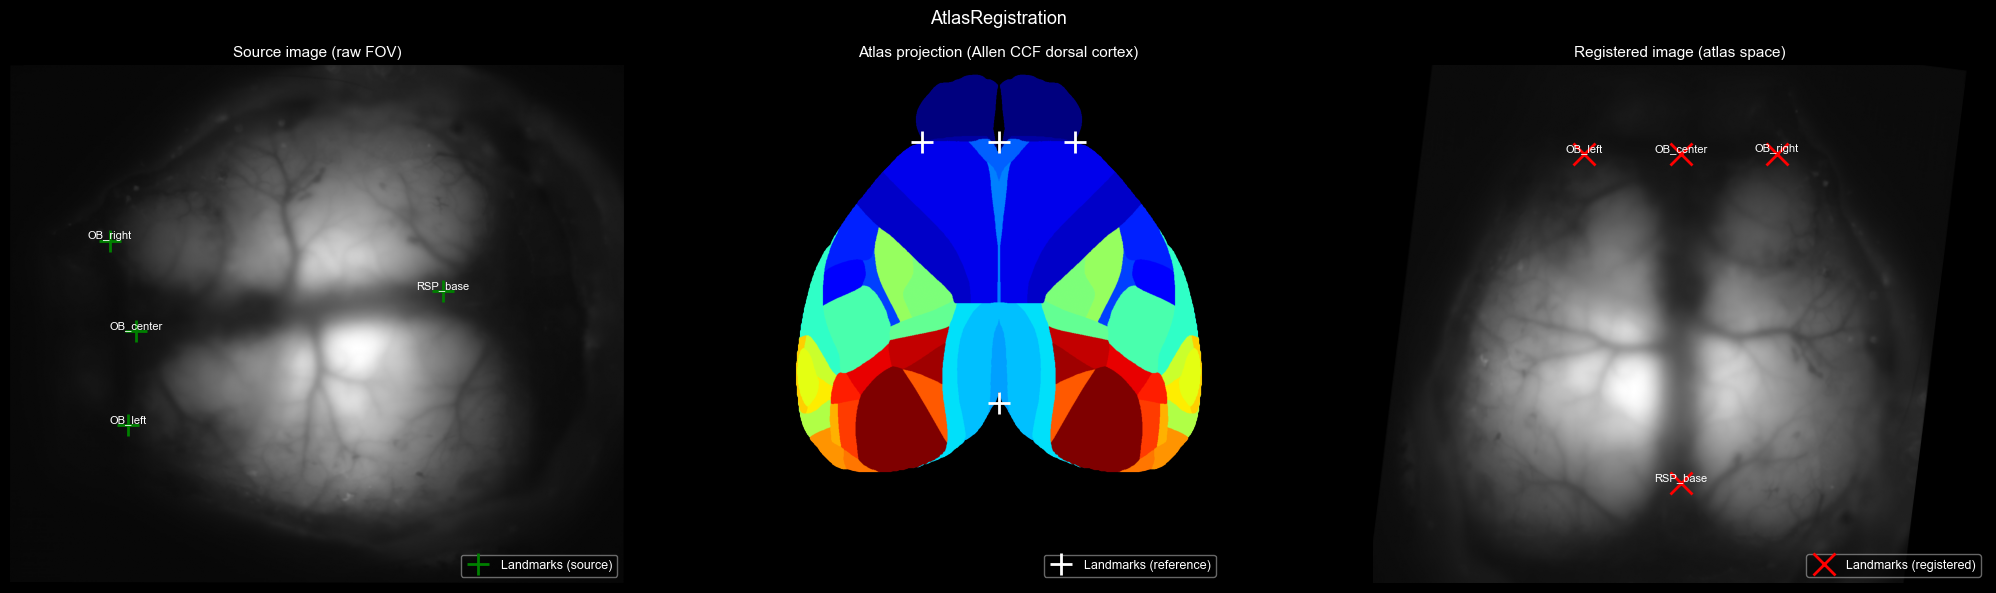

In [6]:
# Load images for use throughout the notebook
source_img = atlas_registration.source_image.data[:]
registered_img = atlas_registration.registered_image.data[:]
atlas_proj = atlas_registration.atlas_projection.data[:]
landmarks_df = landmarks[:]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# --- Source image ---
axes[0].imshow(source_img, cmap="gray")
axes[0].plot(
    landmarks_df["source_x"], landmarks_df["source_y"],
    "g+", ms=16, mew=2, label="Landmarks (source)",
)
for _, row in landmarks_df.iterrows():
    axes[0].text(
        row["source_x"], row["source_y"], row["landmark_labels"],
        color="w", fontsize=8, va="bottom", ha="center",
    )
axes[0].set_title("Source image (raw FOV)", fontsize=11)
axes[0].axis("off")
axes[0].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

# --- Atlas projection ---
proj_masked = np.ma.masked_equal(atlas_proj, 0)
cmap_jet = plt.get_cmap("jet").copy()
cmap_jet.set_bad(alpha=0)
axes[1].imshow(proj_masked, cmap=cmap_jet)
axes[1].plot(
    landmarks_df["reference_x"], landmarks_df["reference_y"],
    "w+", ms=16, mew=2, label="Landmarks (reference)",
)
axes[1].set_title("Atlas projection (Allen CCF dorsal cortex)", fontsize=11)
axes[1].axis("off")
axes[1].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

# --- Registered image ---
axes[2].imshow(registered_img, cmap="gray")
axes[2].plot(
    landmarks_df["registered_x"], landmarks_df["registered_y"],
    "rx", ms=16, mew=2, label="Landmarks (registered)",
)
for _, row in landmarks_df.iterrows():
    axes[2].text(
        row["registered_x"], row["registered_y"], row["landmark_labels"],
        color="w", fontsize=8, va="bottom", ha="center",
    )
axes[2].set_title("Registered image (atlas space)", fontsize=11)
axes[2].axis("off")
axes[2].legend(loc="lower right", fontsize=9, frameon=True, facecolor="black", framealpha=0.5)

plt.suptitle("AtlasRegistration", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Anatomical Coordinates Image <a id="aci"></a>

`AnatomicalCoordinatesImage` assigns physical anatomical coordinates to every pixel
in a registered image. It is stored inside the `Localization` container at
`nwbfile.lab_meta_data["localization"]`.

| Field | Shape | Description |
|---|---|---|
| `x` | `(H, W)` | Per-pixel X coordinate in the named `Space` |
| `y` | `(H, W)` | Per-pixel Y coordinate |
| `z` | `(H, W)` | Per-pixel Z coordinate |
| `brain_region` | `(H, W)` | Per-pixel Allen acronym string (`"out-of-atlas"` for pixels outside the atlas) |
| `space` | `Space` | Coordinate frame: origin, units, orientation |
| `image` | `GrayscaleImage` | The registered image these coordinates describe |
| `method` | `str` | Description of the registration method |

For IBL sessions, the coordinate space is **IBL Bregma (RAS)**:

| Axis | Direction | Anatomical axis |
|---|---|---|
| x | positive = **R**ight | Mediolateral (ML) |
| y | positive = **A**nterior | Anteroposterior (AP) |
| z | positive = **S**uperior | Dorsoventral (DV) |

All coordinates are in **µm**, with **bregma** as the origin.
Because the FOV is a 2-D projection, z ≈ 0 for all pixels.

In [7]:
localization = nwbfile.lab_meta_data["localization"]
aci = localization.anatomical_coordinates_images["RegisteredImageAnatomicalCoordinatesIBLBregma"]

space = aci.space
x_coords = aci.x[:]   # ML in µm
y_coords = aci.y[:]   # AP in µm
region_names = np.asarray(aci.brain_region[:])

in_atlas = region_names != "out-of-atlas"

print(f"Name            : {aci.name}")
print(f"Description     : {aci.description}")
print(f"Space           : {space.space_name}")
print(f"  Origin        : {space.origin}")
print(f"  Units         : {space.units}")
print(f"  Orientation   : {space.orientation}  "
      f"(x={space.orientation[0]}, y={space.orientation[1]}, z={space.orientation[2]})")
print(f"Image shape     : {aci.image.data[:].shape}")
print(f"ML (x) range    : [{x_coords[in_atlas].min():.0f}, {x_coords[in_atlas].max():.0f}] µm")
print(f"AP (y) range    : [{y_coords[in_atlas].min():.0f}, {y_coords[in_atlas].max():.0f}] µm")
print(f"Brain regions   : {len(np.unique(region_names[in_atlas]))} unique acronyms in atlas")

Name            : RegisteredImageAnatomicalCoordinatesIBLBregma
Description     : Transformed mean image estimated coordinates in IBL bregma-centered coordinate system.
Space           : IBLBregma
  Origin        : bregma
  Units         : um
  Orientation   : RAS  (x=R, y=A, z=S)
Image shape     : (540, 640)
ML (x) range    : [-5160, 5160] µm
AP (y) range    : [-8416, 1710] µm
Brain regions   : 33 unique acronyms in atlas


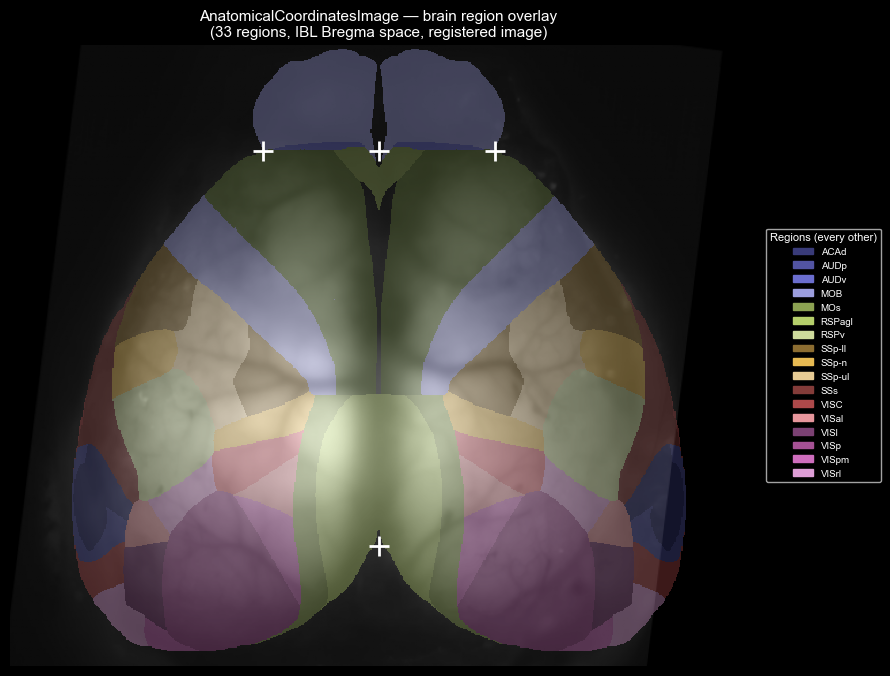

In [8]:
# Brain region overlay on the registered image
background = "out-of-atlas"
names = np.unique(region_names)
names = names[names != background]
n = len(names)

# Integer label image (0 = background / out-of-atlas)
name_to_idx = {name: i + 1 for i, name in enumerate(names)}
idx_img = np.zeros(region_names.shape, dtype=np.int16)
for name, i in name_to_idx.items():
    idx_img[region_names == name] = i

idx_masked = np.ma.masked_where(idx_img == 0, idx_img)

# One colour per region (tab20b recycled if more than 20)
base_cmap = plt.get_cmap("tab20b", max(n, 1))
colors = np.vstack([[0, 0, 0, 0], base_cmap(np.arange(n))])
region_cmap = ListedColormap(colors)
region_cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(registered_img, cmap="gray")
ax.imshow(idx_masked, cmap=region_cmap, alpha=0.35, interpolation="nearest")
ax.plot(
    landmarks_df["registered_x"], landmarks_df["registered_y"],
    "w+", ms=14, mew=2, label="Landmarks",
)
ax.set_title(
    "AnatomicalCoordinatesImage — brain region overlay\n"
    f"({n} regions, IBL Bregma space, registered image)",
    fontsize=11,
)
ax.axis("off")
ax.legend(loc="lower right", fontsize=9)

# Legend: every other region to keep it readable
handles = [
    mpatches.Patch(color=region_cmap(name_to_idx[name]), label=name)
    for name in names[::2]
]
ax.legend(
    handles=handles,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, title="Regions (every other)",
    fontsize=7, title_fontsize=8,
)

plt.tight_layout()
plt.show()

---
## 4. Brain Region Masks <a id="brm"></a>

`BrainRegionMasks` is a **sparse** `DynamicTable` with one row per in-atlas pixel.
Each row maps a pixel position to its Allen brain region integer ID.

| Column | Dtype | Description |
|---|---|---|
| `x` | `uint32` | Pixel column index |
| `y` | `uint32` | Pixel row index |
| `brain_region_id` | `uint32` | Allen Brain Atlas integer structure ID |

**Convenience method**: `._to_image(image_height, image_width)` reconstructs the dense
`(H, W)` integer array from the sparse table (background pixels are 0).

The sparse representation is useful when you want to filter or group pixels by region ID
without loading a full 2-D array.

Two masks are stored per session, both under `nwbfile.lab_meta_data["localization"].brain_region_masks`:

| Name | Image space |
|---|---|
| `RegisteredImageBrainRegionMasksIBLBregma` | Registered (atlas-aligned) FOV |
| `SourceImageBrainRegionMasksIBLBregma` | Raw (source / camera) FOV — masks warped back via inverse affine |

In [9]:
print("Available BrainRegionMasks:")
for name, masks in localization.brain_region_masks.items():
    print(f"  {name}")
    print(f"    rows (in-atlas pixels) : {len(masks)}")
    print(f"    unique region IDs      : {np.unique(masks['brain_region_id'].data[:]).shape[0]}")

reg_masks = localization.brain_region_masks["RegisteredImageBrainRegionMasksIBLBregma"]
src_masks = localization.brain_region_masks["SourceImageBrainRegionMasksIBLBregma"]

# Reconstruct dense 2-D arrays
H, W = registered_img.shape
reg_id_img = reg_masks._to_image(image_height=H, image_width=W)
src_id_img = src_masks._to_image(image_height=source_img.shape[0], image_width=source_img.shape[1])

print(f"\nDense array shape (registered): {reg_id_img.shape}, dtype: {reg_id_img.dtype}")
print(f"Dense array shape (source):     {src_id_img.shape}, dtype: {src_id_img.dtype}")

Available BrainRegionMasks:
  RegisteredImageBrainRegionMasksIBLBregma
    rows (in-atlas pixels) : 204542
    unique region IDs      : 33
  SourceImageBrainRegionMasksIBLBregma
    rows (in-atlas pixels) : 192088
    unique region IDs      : 33

Dense array shape (registered): (540, 640), dtype: int32
Dense array shape (source):     (540, 640), dtype: int32


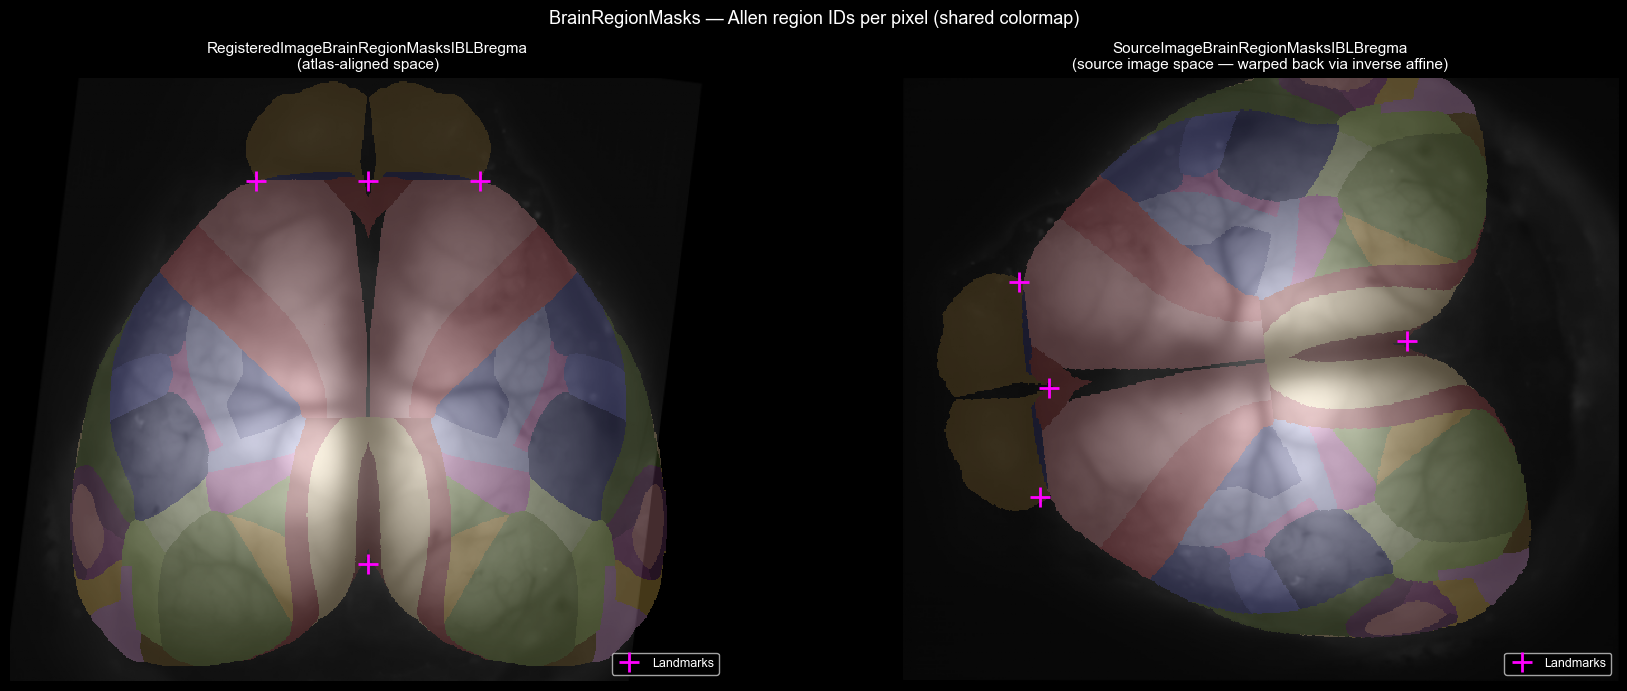

In [13]:
# Build a shared colormap indexed by Allen region ID (shared between both images)
unique_ids = np.unique(reg_id_img[reg_id_img != 0])
n_ids = len(unique_ids)
id_to_cmap_idx = {int(rid): i + 1 for i, rid in enumerate(unique_ids)}
id_to_cmap_idx[0] = 0

base_cmap = plt.get_cmap("tab20b", max(n_ids, 1))
colors = np.vstack([[0, 0, 0, 0], base_cmap(np.arange(n_ids))])
mask_cmap = ListedColormap(colors)
mask_cmap.set_bad(alpha=0)


def id_img_to_display(id_img):
    """Convert an integer Allen-ID image to colormap-index image and mask background."""
    cmap_img = np.vectorize(id_to_cmap_idx.get)(id_img)
    return np.ma.masked_where(cmap_img == 0, cmap_img)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -- Registered space --
axes[0].imshow(registered_img, cmap="gray")
axes[0].imshow(id_img_to_display(reg_id_img), cmap=mask_cmap, alpha=0.3, interpolation="nearest")
axes[0].plot(
    landmarks_df["registered_x"], landmarks_df["registered_y"],
    "+", color="magenta", ms=14, mew=2, label="Landmarks",
)
axes[0].set_title(
    "RegisteredImageBrainRegionMasksIBLBregma\n(atlas-aligned space)",
    fontsize=11,
)
axes[0].axis("off")
axes[0].legend(loc="lower right", fontsize=9)

# -- Source space --
axes[1].imshow(source_img, cmap="gray")
axes[1].imshow(id_img_to_display(src_id_img), cmap=mask_cmap, alpha=0.3, interpolation="nearest")
axes[1].plot(
    landmarks_df["source_x"], landmarks_df["source_y"],
    "+", color="magenta", ms=14, mew=2, label="Landmarks",
)
axes[1].set_title(
    "SourceImageBrainRegionMasksIBLBregma\n(source image space — warped back via inverse affine)",
    fontsize=11,
)
axes[1].axis("off")
axes[1].legend(loc="lower right", fontsize=9)

plt.suptitle(
    "BrainRegionMasks — Allen region IDs per pixel (shared colormap)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

---
## 5. Anatomical Coordinates Tables <a id="act"></a>

`AnatomicalCoordinatesTable` stores 3-D anatomical coordinates for a set of **discrete objects**
(here: the registration landmarks). Each row gives `(x, y, z)` in a named `Space` and a
back-reference (`localized_entity`) to the corresponding row in the target table (i.e. `Landmarks`).

Two coordinate systems are stored for the IBL landmarks,
both under `nwbfile.lab_meta_data["localization"].anatomical_coordinates_tables`:

| Name | Space | Orientation | Description |
|---|---|---|---|
| `AnatomicalCoordinatesIBLBregma` | IBL Bregma | RAS | x = ML, y = AP, z = DV, bregma = origin, units µm |
| `AnatomicalCoordinatesCCFv3` | Allen CCFv3 | PIR | x = AP, y = DV, z = ML, ASL corner = origin, units µm |

The `localized_entity` column is a `DynamicTableRegion` pointing back to the `Landmarks` table,
so each coordinate row is directly linked to its landmark.

In [11]:
ibl_table = localization.anatomical_coordinates_tables["AnatomicalCoordinatesIBLBregma"]

print(f"Space    : {ibl_table.space.space_name}")
print(f"  Origin : {ibl_table.space.origin}")
print(f"  Orient : {ibl_table.space.orientation}  "
      f"(x={ibl_table.space.orientation[0]}, "
      f"y={ibl_table.space.orientation[1]}, "
      f"z={ibl_table.space.orientation[2]})")
print(f"  Units  : {ibl_table.space.units}")
print(f"Method   : {ibl_table.method}")
print(f"Description: {ibl_table.description}")
print()
ibl_table[:]

Space    : IBLBregma
  Origin : bregma
  Orient : RAS  (x=R, y=A, z=S)
  Units  : um
Method   : IBL manual annotation
Description: IBL bregma-centered coordinates of landmarks. Coordinates are in um in the IBL frame (RAS: x=ML, y=AP, z=DV).



,x,y,z,localized_entity,brain_region
id,,,,,
0,-1950.0,-3450.0,0.0,0,OB_left
1,0.0,-3450.0,0.0,1,OB_center
2,1950.0,-3450.0,0.0,2,OB_right
3,0.0,3200.0,0.0,3,RSP_base


In [12]:
ccf_table = localization.anatomical_coordinates_tables["AnatomicalCoordinatesCCFv3"]

print(f"Space    : {ccf_table.space.space_name}")
print(f"  Origin : {ccf_table.space.origin}")
print(f"  Orient : {ccf_table.space.orientation}  "
      f"(x={ccf_table.space.orientation[0]}, "
      f"y={ccf_table.space.orientation[1]}, "
      f"z={ccf_table.space.orientation[2]})")
print(f"  Units  : {ccf_table.space.units}")
print(f"Method   : {ccf_table.method}")
print(f"Description: {ccf_table.description}")
print()
ccf_table[:]

Space    : AllenCCFv3
  Origin : Anterior-Superior-Left (ASL) corner of the 3D image volume
  Orient : PIR  (x=P, y=I, z=R)
  Units  : um
Method   : IBL manual annotation
Description: CCF coordinates of landmarks. Coordinates are in the native Allen CCF format with PIR+ orientation (x=AP, y=DV, z=ML).



,x,y,z,localized_entity,brain_region
id,,,,,
0,8850.0,332.0,3789.0,0,OB_left
1,8850.0,332.0,5739.0,1,OB_center
2,8850.0,332.0,7689.0,2,OB_right
3,2200.0,332.0,5739.0,3,RSP_base
